In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import os
import tarfile
import urllib.request
import pandas as pd

DOWNLOAD_ROOT = "https://github.com/ageron/data/raw/main/"
HOUSING_PATH = os.path.join("data", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

fetch_housing_data()
df = pd.read_csv(os.path.join(HOUSING_PATH, "housing.csv"))

In [14]:
file_path = r'data/housing/housing.csv'
df = pd.read_csv(file_path)

In [15]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [17]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [18]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [19]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(col, df[col].isna().sum())

total_bedrooms 207


In [20]:
numerical_df = df.select_dtypes(np.number)
numerical_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [21]:
categorical_df = df.select_dtypes(include=['category'])
categorical_df

""
0
1
2
3
4
...
20635
20636
20637
20638


In [22]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    print(f"\n--- {col} ---")
    
    mean = df[col].mean()
    median = df[col].median()
    skew = df[col].skew()
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"mean: {mean:.2f}, median: {median:.2f}, skew: {skew:.2f}")
    print(f"outliers: {len(outliers)}")
    
    if skew > 1:
        print("→ heavily right-skewed")
    elif skew > 0.5:
        print("→ moderately right-skewed")
    elif skew < -1:
        print("→ heavily left-skewed")
    elif skew < -0.5:
        print("→ moderately left-skewed")
    else:
        print("→ approximately normal")
    
    if len(outliers) > 0:
        print("→ outliers detected")
    else:
        print("→ no significant outliers")


--- longitude ---
mean: -119.57, median: -118.49, skew: -0.30
outliers: 0
→ approximately normal
→ no significant outliers

--- latitude ---
mean: 35.63, median: 34.26, skew: 0.47
outliers: 0
→ approximately normal
→ no significant outliers

--- housing_median_age ---
mean: 28.64, median: 29.00, skew: 0.06
outliers: 0
→ approximately normal
→ no significant outliers

--- total_rooms ---
mean: 2635.76, median: 2127.00, skew: 4.15
outliers: 1287
→ heavily right-skewed
→ outliers detected

--- total_bedrooms ---
mean: 537.87, median: 435.00, skew: 3.46
outliers: 1271
→ heavily right-skewed
→ outliers detected

--- population ---
mean: 1425.48, median: 1166.00, skew: 4.94
outliers: 1196
→ heavily right-skewed
→ outliers detected

--- households ---
mean: 499.54, median: 409.00, skew: 3.41
outliers: 1220
→ heavily right-skewed
→ outliers detected

--- median_income ---
mean: 3.87, median: 3.53, skew: 1.65
outliers: 681
→ heavily right-skewed
→ outliers detected

--- median_house_value ---


In [23]:
def missing_report(df):
    
    data = []
    
    for column_name in df.columns:
        if df[column_name].isna().sum() > 0:
            data.append([column_name, df[column_name].isna().sum(), df[column_name].isna().sum() / len(df) * 100])
    
    return pd.DataFrame(data=data, columns=["Name", "Count", "Percentage"])

missing_report(df)

,Name,Count,Percentage
0,total_bedrooms,207,1.002907


In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

imputer.fit(numerical_df)

data = imputer.transform(numerical_df)

numerical_df = pd.DataFrame(data=data, columns=imputer.feature_names_in_)

In [25]:
df = pd.concat([numerical_df, categorical_df], axis=1)
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [26]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
enc.fit(categorical_df)

one_hot_encoded = pd.DataFrame(data=enc.transform(categorical_df).toarray(), columns=enc.get_feature_names_out()).astype(int)
one_hot_encoded

""
0
1
2
3
4
...
20635
20636
20637
20638


In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

cols = ["median_income", "housing_median_age", "population", "median_house_value"]

std_scale = StandardScaler().fit(df[cols])
df_std = std_scale.transform(df[cols])

minmax_scale = MinMaxScaler().fit(df[cols])
df_min_max = minmax_scale.transform(df[cols])

In [28]:
df_std = pd.DataFrame(df_std, columns=cols)
df_min_max = pd.DataFrame(df_min_max, columns=cols)
df[cols] = df_min_max
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,0.784314,880.0,129.0,0.008941,126.0,0.539668,0.902266
1,-122.22,37.86,0.392157,7099.0,1106.0,0.067210,1138.0,0.538027,0.708247
2,-122.24,37.85,1.000000,1467.0,190.0,0.013818,177.0,0.466028,0.695051
3,-122.25,37.85,1.000000,1274.0,235.0,0.015555,219.0,0.354699,0.672783
4,-122.25,37.85,1.000000,1627.0,280.0,0.015752,259.0,0.230776,0.674638
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,0.470588,1665.0,374.0,0.023599,330.0,0.073130,0.130105
20636,-121.21,39.49,0.333333,697.0,150.0,0.009894,114.0,0.141853,0.128043
20637,-121.22,39.43,0.313725,2254.0,485.0,0.028140,433.0,0.082764,0.159383
20638,-121.32,39.43,0.333333,1860.0,409.0,0.020684,349.0,0.094295,0.143713


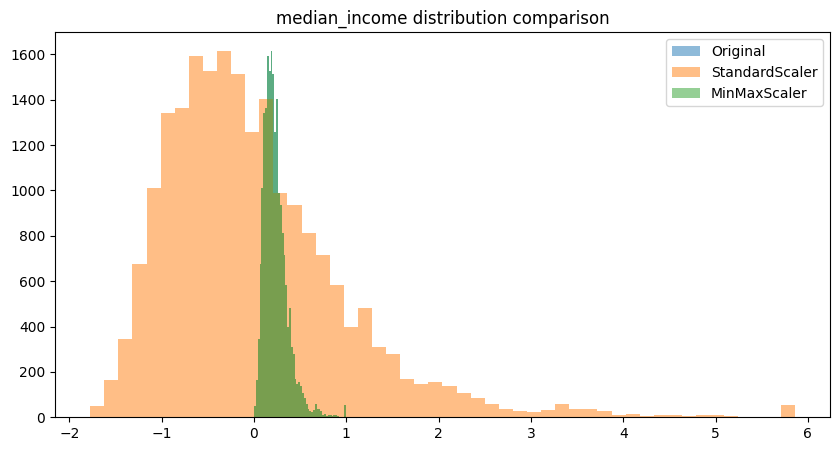

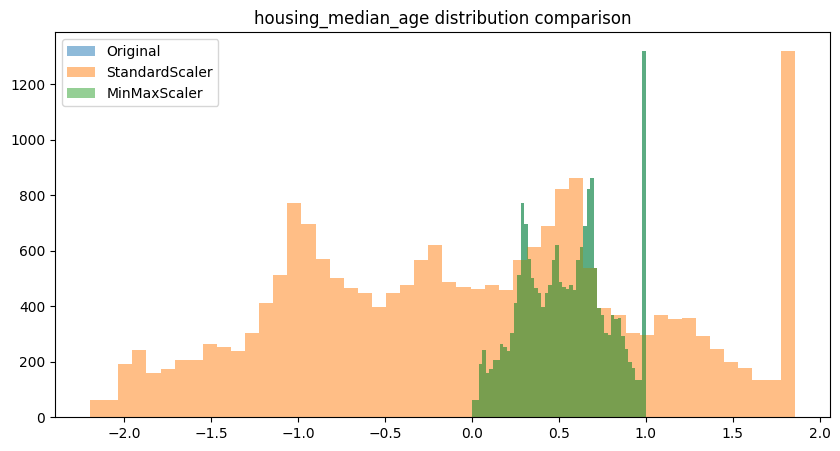

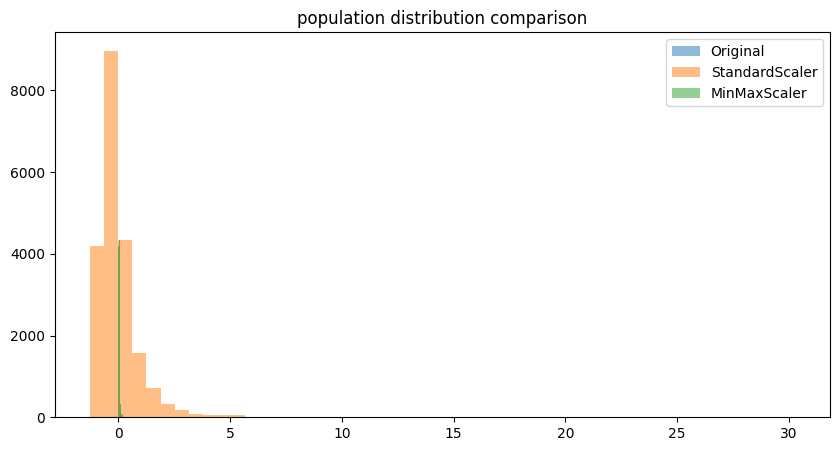

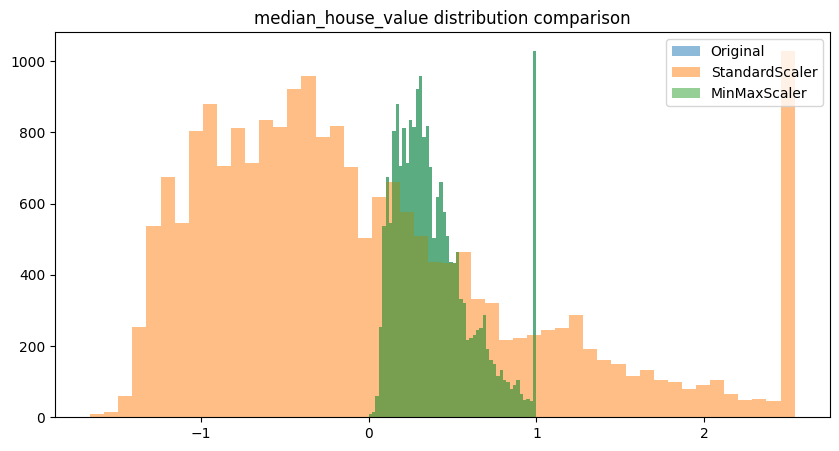

In [29]:
for col in cols:
    plt.figure(figsize=(10,5))
    
    plt.hist(df[col], bins=50, alpha=0.5, label='Original')
    
    plt.hist(df_std[col], bins=50, alpha=0.5, label='StandardScaler')
    
    plt.hist(df_min_max[col], bins=50, alpha=0.5, label='MinMaxScaler')
    
    plt.title(f"{col} distribution comparison")
    plt.legend()
    plt.show()

In [ ]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room "] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,0.784314,880.0,129.0,0.008941,126.0,0.539668,0.902266,6.984127,0.146591,0.000071
1,-122.22,37.86,0.392157,7099.0,1106.0,0.067210,1138.0,0.538027,0.708247,6.238137,0.155797,0.000059
2,-122.24,37.85,1.000000,1467.0,190.0,0.013818,177.0,0.466028,0.695051,8.288136,0.129516,0.000078
3,-122.25,37.85,1.000000,1274.0,235.0,0.015555,219.0,0.354699,0.672783,5.817352,0.184458,0.000071
4,-122.25,37.85,1.000000,1627.0,280.0,0.015752,259.0,0.230776,0.674638,6.281853,0.172096,0.000061
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,0.470588,1665.0,374.0,0.023599,330.0,0.073130,0.130105,5.045455,0.224625,0.000072
20636,-121.21,39.49,0.333333,697.0,150.0,0.009894,114.0,0.141853,0.128043,6.114035,0.215208,0.000087
20637,-121.22,39.43,0.313725,2254.0,485.0,0.028140,433.0,0.082764,0.159383,5.205543,0.215173,0.000065
20638,-121.32,39.43,0.333333,1860.0,409.0,0.020684,349.0,0.094295,0.143713,5.329513,0.219892,0.000059


In [30]:
df.to_csv(file_path, index=False)